In [1]:
from astropy.io import fits
import numpy as np
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.coordinates import Angle
hdul = fits.open('galah_dr4_allstar_240705.fits')

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


CHOOSING STARS 
Goal of this is to have a variety of stars to map. To do so, we will use effective temperature, metallicity and radial velocity to differentiate the stars. We will use GALAH to survey this and choose 15 source IDs. 

In [3]:
data = hdul[1].data

star_IDs = []

filter1 = data[(data['fe_h'] < -0.1)]
sample = np.random.choice(len(filter1), 3, replace=False)
stargroup1 = filter1[sample]["gaiadr3_source_id"]
print("Star IDs with low metallicity - ", stargroup1 )

filter2 = data[(data['fe_h'] > 0.1)]
sample2 = np.random.choice(len(filter2), 2, replace=False)
stargroup2 = filter2[sample2]["gaiadr3_source_id"]
print("Star IDs with high metallicity - ", stargroup2 )

filter3 = data[(data['fe_h'] < np.abs(0.1))]
sample3 = np.random.choice(len(filter3), 1, replace=False)
stargroup3 = filter3[sample3]["gaiadr3_source_id"]
print("Star IDs with metallicity < abs(0.1) - ", stargroup3 )

filter4 = data[(data['teff'] > 5000)]
sample4 = np.random.choice(len(filter4), 2, replace=False)
stargroup4 = filter4[sample4]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 5000 - ", stargroup4 )


filter5 = data[(data['teff'] < 5000)]
sample5 = np.random.choice(len(filter5), 2, replace=False)
stargroup5 = filter5[sample5]["gaiadr3_source_id"]
print("Star IDs with effective temperature < 5000 - ", stargroup5 )

filter6 = data[(data['teff'] > 7500)]
sample6 = np.random.choice(len(filter6), 1, replace=False)
stargroup6 = filter6[sample6]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 7500 - ", stargroup6 )

filter7 = data[(data['rv_comp_1'] > 14.5)]
sample7 = np.random.choice(len(filter7), 1, replace=False)
stargroup7 = filter7[sample7]["gaiadr3_source_id"]
print("Star IDs with radial velocity 1 > 10 - ", stargroup7 )


filter8 = data[(data['rv_comp_1'] > -5) & (data['rv_comp_1'] < 5)]
sample8 = np.random.choice(len(filter8), 2, replace=False)
stargroup8 = filter8[sample8]["gaiadr3_source_id"]
print("Star IDs with radial velocity 1 < -10 - ", stargroup8 )

filter9 = data[(data['rv_comp_2'] > np.abs(5))]
sample9 = np.random.choice(len(filter9), 1, replace=False)
stargroup9 = filter9[sample9]["gaiadr3_source_id"]
print("Star IDs with radial velocity 1 > abs(5) - ", stargroup9 )


star_IDs = np.concatenate([
    stargroup1,
    stargroup2,
    stargroup3,
    stargroup4,
    stargroup5,
    stargroup6,
    stargroup7,
    stargroup8,
    stargroup9
])
print(star_IDs)
#thick_disk = galah[(galah['fe_h'] < -0.3) & (galah['fe_h'] > -1)].sample(3)

#halo = galah[(galah['fe_h'] < -1)].sample(3)

#outlier = galah.sort_values(by='rv_galah', ascending=False).head(1)

#stars = pd.concat([thin_disk, thick_disk, halo, outlier])

Star IDs with low metallicity -  [3468711765453488768 5406167011571438848 5237995776078985728]
Star IDs with high metallicity -  [6084979720744554112 3104508503080578560]
Star IDs with metallicity < abs(0.1) -  [4471780688578138880]
Star IDs with effective temperature > 5000 -  [4488181347613118464 4665865866931521152]
Star IDs with effective temperature < 5000 -  [5407206496733315840 2667678683754221952]
Star IDs with effective temperature > 7500 -  [2565138435506016128]
Star IDs with radial velocity 1 > 10 -  [5567883731523150208]
Star IDs with radial velocity 1 < -10 -  [5827518829602543744 6706199014439640192]
Star IDs with radial velocity 1 > abs(5) -  [6401632983568502016]
[3468711765453488768 5406167011571438848 5237995776078985728
 6084979720744554112 3104508503080578560 4471780688578138880
 4488181347613118464 4665865866931521152 5407206496733315840
 2667678683754221952 2565138435506016128 5567883731523150208
 5827518829602543744 6706199014439640192 6401632983568502016]


In [4]:
star_list = ",".join(str(i) for i in star_IDs)

query = f"""
SELECT source_id, ra, dec, pmra, pmdec, parallax, radial_velocity
FROM gaiadr3.gaia_source
WHERE source_id IN ({star_list})
"""

job = Gaia.launch_job(query)
gaia_results = job.get_results()

In [5]:
coords = SkyCoord(
    ra=gaia_results['ra'],
    dec=gaia_results['dec'], 
    pm_ra_cosdec=gaia_results['pmra'],
    pm_dec=gaia_results['pmdec']
)

In [6]:
print(coords)

<SkyCoord (ICRS): (ra, dec) in deg
    [(266.82895538,   8.45754153), (234.44275974, -61.84883655),
     ( 22.02501457,   6.01970939), (270.93125436, -49.70693414),
     ( 96.51846833,  -4.45743081), (324.16110685,  -6.6254009 ),
     ( 90.48732747, -45.30414422), (185.84347535, -32.66711556),
     (152.72368885, -49.15926325), (320.00822221, -64.94803566),
     (163.7637747 , -68.18971478), (149.12126191, -50.2475154 ),
     (197.3404437 , -49.02327575), (273.26966131,   6.29293011),
     ( 58.75988063, -71.13997797)]
 (pm_ra_cosdec, pm_dec) in mas / yr
    [(  0.08458953,  -1.32528937), (  3.82284679,  -3.40303971),
     ( -5.64274459, -18.88632254), ( -3.01273461, -18.38664169),
     ( -0.39586825,   2.57512138), (  1.14834828,  -6.72710446),
     (  7.6315472 ,   6.92759956), ( -3.4492392 ,  -3.61390666),
     ( -5.2591407 ,   4.1465318 ), (  1.69195611,  -4.3530678 ),
     ( -1.5582602 ,   2.0397277 ), ( -7.27601268,  -2.03320413),
     (-37.61195114,  15.52900444), (  5.99943438,

In [7]:
galactic_coords = coords.galactic
l = galactic_coords.l.degree
b = galactic_coords.b.degree
galactic_coords

<SkyCoord (Galactic): (l, b) in deg
    [( 33.31438908,  18.06896018), (321.25384237,  -5.04654495),
     (139.25199435, -55.6860232 ), (343.4721395 , -13.22886106),
     (214.02808249,  -7.66821338), ( 47.66754711, -39.50161685),
     (252.31281748, -27.27464881), (296.1244122 ,  29.83340355),
     (277.86566469,   5.73895236), (329.00844048, -39.84144569),
     (292.42697804,  -7.72447019), (276.64138037,   3.47585527),
     (305.95525483,  13.74322565), ( 34.22056812,  11.38227007),
     (285.50685415, -39.17652815)]
 (pm_l_cosb, pm_b) in mas / yr
    [( -1.15551816,  -0.65446548), (  1.06021981,  -5.00707208),
     ( -0.71195227, -19.69839764), (-17.79384312,  -5.52488093),
     ( -2.47689556,   0.80805333), ( -5.2558325 ,  -4.35302916),
     ( -5.18578287,   8.9072894 ), ( -2.9691662 ,  -4.01766406),
     ( -6.68773816,   0.35559135), ( -4.66919722,   0.10252837),
     ( -2.29261914,   1.15436626), ( -4.47579687,  -6.08617466),
     (-36.40386335,  18.18151757), ( 10.55008743,  -1

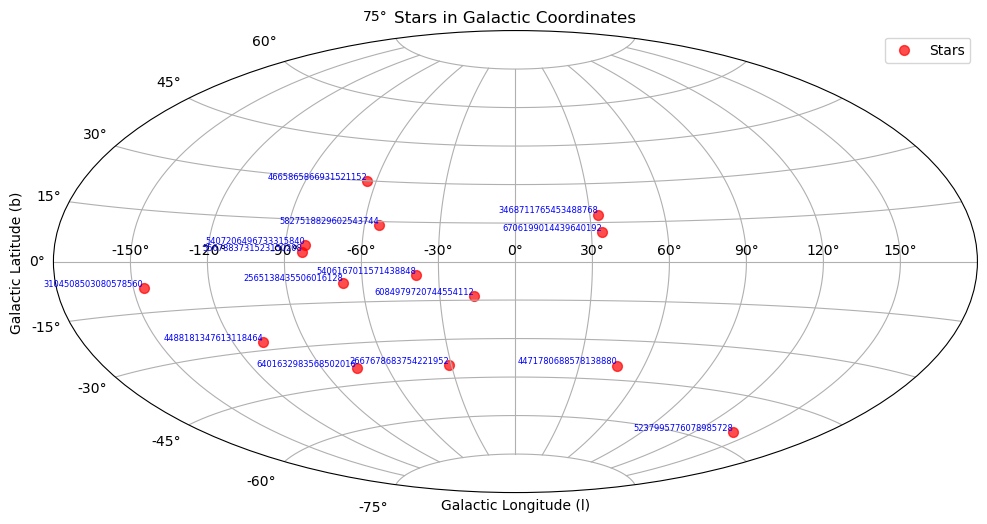

In [23]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian  # wrap to [-180, 180]
b_rad = galactic_coords.b.radian

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)

# Plot stars
ax.scatter(l_rad, b_rad, color='red', s=50, alpha=0.7, label="Stars")

for i, sid in enumerate(star_IDs):
    ax.text(
        l_rad[i], b_rad[i], str(sid), 
        fontsize=6, ha='right', va='bottom', color='blue'
    )

ax.set_title("Stars in Galactic Coordinates")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()

plt.show()

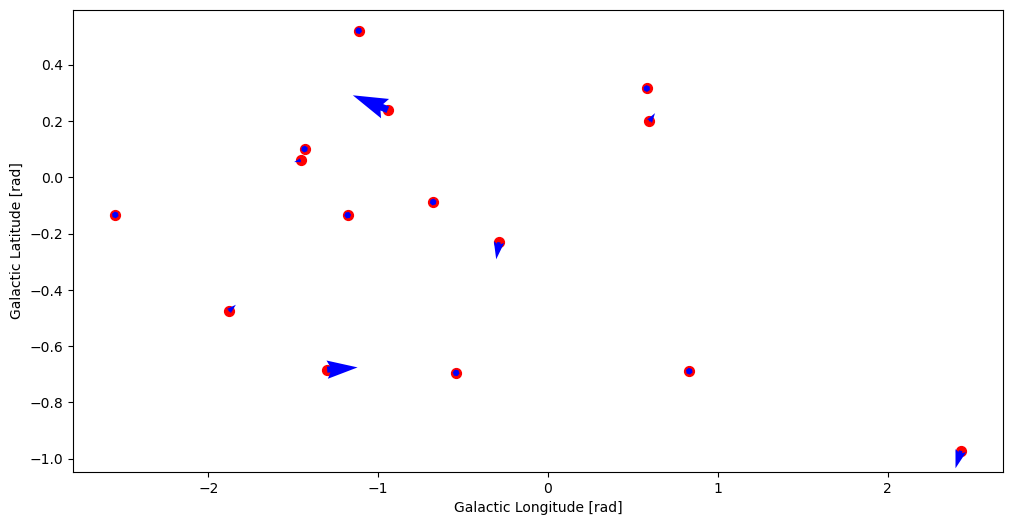

In [27]:
fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(l_rad, b_rad, color='red', s=50)
ax.quiver(l_rad, b_rad, pm_l, pm_b, color='blue', scale=1)
ax.set_xlabel("Galactic Longitude [rad]")
ax.set_ylabel("Galactic Latitude [rad]")
plt.show()